In [3]:
import pandas_datareader as pdr

In [2]:
pip install pandas_datareader

Note: you may need to restart the kernel to use updated packages.


In [4]:
from pandas_datareader import wb
wb.search("gdp.*capita.*constant").head()
wb.get_countries().head()

,iso3c,iso2c,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,,High income,Not classified,Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,,Aggregates,Aggregates,,NaN,NaN
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan","Middle East, North Africa, Afghanistan & Pakis...",Low income,IDA,Kabul,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,,Aggregates,Aggregates,,NaN,NaN
4,AFW,ZI,Africa Western and Central,Aggregates,,Aggregates,Aggregates,,NaN,NaN


In [5]:
data = wb.download(
    indicator="NY.GDP.PCAP.KD",
    country="IND",
    start=1990,
    end=2024
)

data.head()

NY.GDP.PCAP.KD
country year                
India   2024     2366.832891
        2023     2229.714912
        2022     2098.211245
        2021     1965.309434
        2020     1806.501106

In [6]:
wb.search("gdp.*capita.*constant").head(10)

,id,name,unit,source,sourceNote,sourceOrganization,topics
691,6.0.GDPpc_constant,"GDP per capita, PPP (constant 2011 internation...",,LAC Equity Lab,GDP per capita based on purchasing power parit...,b'World Development Indicators (World Bank)',Economy & Growth
11479,NY.GDP.PCAP.KD,GDP per capita (constant 2015 US$),,World Development Indicators,Gross domestic product is the total income ear...,"b'Country official statistics, National Statis...",Economy & Growth
11481,NY.GDP.PCAP.KN,GDP per capita (constant LCU),,World Development Indicators,Gross domestic product is the total income ear...,"b'Country official statistics, National Statis...",Economy & Growth
11483,NY.GDP.PCAP.PP.KD,"GDP per capita, PPP (constant 2021 internation...",,World Development Indicators,This indicator provides values for gross domes...,"b'International Comparison Program (ICP), Worl...",Economy & Growth
11484,NY.GDP.PCAP.PP.KD.87,"GDP per capita, PPP (constant 1987 internation...",,WDI Database Archives,,b'',


In [7]:
data = data.sort_index(level="year")
data.head()

NY.GDP.PCAP.KD
country year                
India   1990      537.870270
        1991      531.898398
        1992      549.235070
        1993      563.372872
        1994      588.727892

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 35 entries, ('India', '1990') to ('India', '2024')
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NY.GDP.PCAP.KD  35 non-null     float64
dtypes: float64(1)
memory usage: 1.9+ KB


In [9]:
data.shape

(35, 1)

In [10]:
values = data["NY.GDP.PCAP.KD"].values

In [11]:
print(values)

[ 537.87026954  531.89839783  549.23506996  563.37287234  588.72789218
  620.69995434  654.35592843  667.59842309  695.29370934  742.5392084
  756.70410953  778.50737752  793.6159129   841.27889456  892.59661458
  947.73256564 1008.23275345 1069.24696812 1086.50605251 1155.10163274
 1235.15939133 1281.61054355 1333.09626558 1399.45379803 1484.31640683
 1583.99815908 1694.46534974 1788.69770318 1883.35772705 1936.03067741
 1806.50110584 1965.30943437 2098.21124476 2229.71491223 2366.83289103]


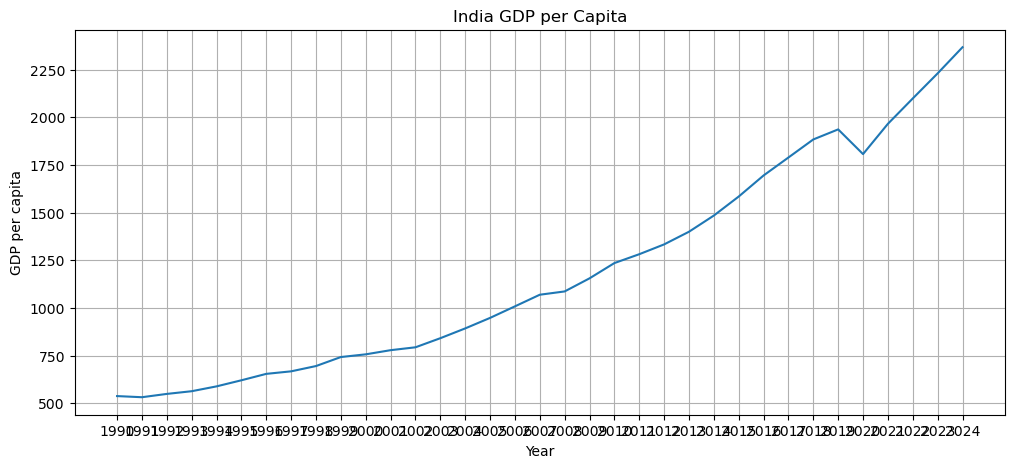

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(data.index.get_level_values("year"),values)


plt.xlabel("Year")
plt.ylabel("GDP per capita")
plt.title("India GDP per Capita")
plt.grid(True)
plt.show()

In [14]:
values = data["NY.GDP.PCAP.KD"].values

In [15]:
print(values.shape)

(35,)


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_values = scaler.fit_transform(values.reshape(-1, 1))

In [17]:
print(scaled_values[:5])

[[0.00325454]
 [0.        ]
 [0.00944812]
 [0.01715291]
 [0.03097086]]


In [18]:
sequence_length = 5

X = []
y = []

for i in range(sequence_length, len(scaled_values)):
    X.append(scaled_values[i-sequence_length:i, 0])
    y.append(scaled_values[i, 0])

In [19]:
import numpy as np

X = np.array(X)
y = np.array(y)

In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 5)
y shape: (30,)


In [21]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print("X shape:", X.shape)

X shape: (30, 5, 1)


In [22]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24, 5, 1)
X_test : (6, 5, 1)
y_train: (24,)
y_test : (6,)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [24]:
model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(5, 1)))

model.add(Dense(1))

C:\Users\atish\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=4,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.1218 - val_loss: 0.5166
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0767 - val_loss: 0.3502
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0492 - val_loss: 0.2029
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0201 - val_loss: 0.1035
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0138 - val_loss: 0.0360
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0135 - val_loss: 0.0130
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0120 - val_loss: 0.0129
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0088 - val_loss: 0.0176
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0071 - val_loss: 0.0200
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0057 - val_loss: 0.0145
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0043 - val_loss: 0.0055
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0028 - val_l

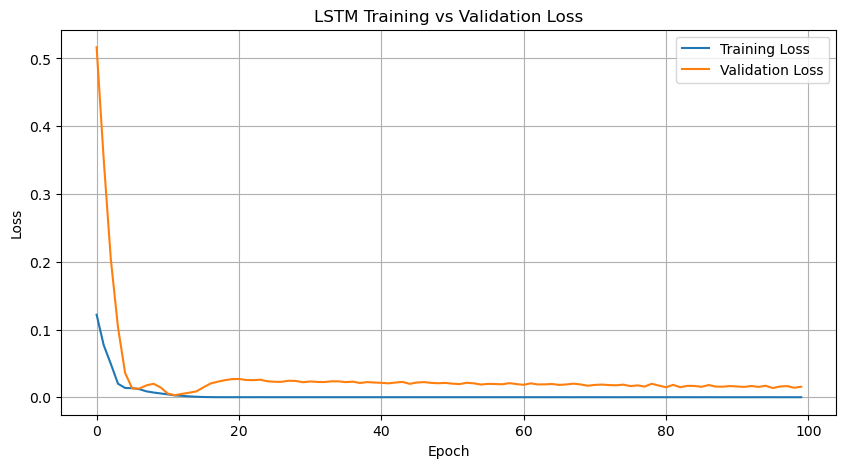

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


In [29]:
predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


In [30]:
print(predictions.shape)

(6, 1)


In [31]:
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [32]:
print("Predictions:")
print(predictions)

print("\nActual:")
print(actual)

Predictions:
[[2029.6381]
 [2161.2808]
 [2256.6848]
 [2330.9287]
 [2400.539 ]
 [2473.2156]]

Actual:
[[1936.03067741]
 [1806.50110584]
 [1965.30943437]
 [2098.21124476]
 [2229.71491223]
 [2366.83289103]]


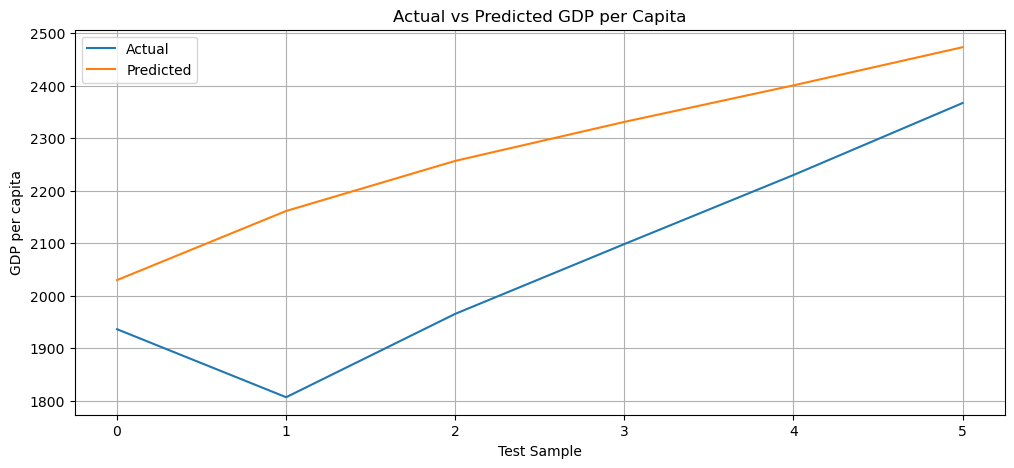

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.xlabel("Test Sample")
plt.ylabel("GDP per capita")
plt.title("Actual vs Predicted GDP per Capita")
plt.legend()
plt.grid(True)

plt.show()

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [35]:
mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(mean_squared_error(actual, predictions))

r2 = r2_score(actual, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 208.28112027613295
RMSE: 228.83259666512953
R²  : -0.4771078183912367


In [37]:
data = wb.download(
    indicator="NY.GDP.PCAP.KD",
    country="IND",
    start=1960,
    end=2024
)

data = data.sort_index(level="year")

print(data.shape)
print(data.head())
print(data.tail())

(65, 1)
              NY.GDP.PCAP.KD
country year                
India   1960      312.777848
        1961      316.739645
        1962      318.381946
        1963      329.641495
        1964      346.011883
              NY.GDP.PCAP.KD
country year                
India   2020     1806.501106
        2021     1965.309434
        2022     2098.211245
        2023     2229.714912
        2024     2366.832891


In [38]:
values = data["NY.GDP.PCAP.KD"].values

print("Number of observations:", len(values))

Number of observations: 65


In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_values = scaler.fit_transform(values.reshape(-1, 1))

In [40]:
sequence_length = 5

X = []
y = []

for i in range(sequence_length, len(scaled_values)):
    X.append(scaled_values[i-sequence_length:i, 0])
    y.append(scaled_values[i, 0])

import numpy as np

X = np.array(X)
y = np.array(y)

print("X shape before reshape:", X.shape)
print("y shape:", y.shape)

X shape before reshape: (60, 5)
y shape: (60,)


In [41]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print("X shape:", X.shape)

X shape: (60, 5, 1)


In [42]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (48, 5, 1)
X_test : (12, 5, 1)
y_train: (48,)
y_test : (12,)


In [43]:
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=False,
        input_shape=(5, 1)
    )
)

model.add(Dense(1))

C:\Users\atish\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [45]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=4,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0212 - val_loss: 0.2536
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0093 - val_loss: 0.0916
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0070 - val_loss: 0.0632
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0039 - val_loss: 0.0377
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0019 - val_loss: 0.0073
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.9455e-04 - val_loss: 0.0043
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1616e-04 - val_loss: 0.0136
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0077e-04 - val_loss: 0.0191
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0799e-04 - val_loss: 0.0153
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.2988e-05 - val_loss: 0.0130
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9.1423e-05 - val_loss: 0.0104
Epoch 12/100
12/12 ━━━━━━━━━

In [47]:
predictions = model.predict(X_test)

print(predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
(12, 1)


In [48]:
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
r2 = r2_score(actual, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 69.75031028900044
RMSE: 105.71258433238475
R²  : 0.8561015680768831


In [50]:
print("Predicted:")
print(predictions.flatten())

print("\nActual:")
print(actual.flatten())

Predicted:
[1439.0236 1515.1732 1592.0109 1670.7272 1763.8048 1868.4373 1979.5018
 2085.3772 2153.5625 2209.1936 2266.4287 2330.1165]

Actual:
[1399.45379803 1484.31640683 1583.99815908 1694.46534974 1788.69770318
 1883.35772705 1936.03067741 1806.50110584 1965.30943437 2098.21124476
 2229.71491223 2366.83289103]
